# FluoroFate — Debug Notebook

Standalone analysis from **Cellpose masks** (skips segmentation, runs tracking + analysis).  
Imports analysis functions from the split modules: `measurement.py`, `segmentation.py`, `tracking.py`, `fate_assignment.py`, `colours.py`, `plotting.py`.

## Inputs needed
- Original multi-channel TIFF
- `masks_stack.tiff` (Cellpose segmentation masks from segmentation stage)

In [ ]:
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import napari

"from measurement import measure_all_cells_in_frame, assign_positive_blobs_to_cells, compute_cell_positivity\n",
from segmentation import segment_fluorescence
from tracking import generate_trackmate_labels
from fate_assignment import (
    assign_persistent_fates, assign_snapshot_fates,
    compute_persistent_percentages, compute_snapshot_percentages,
    filter_by_frame_presence, filter_persistent_by_frame_presence,
)
from colours import (
    COLOUR_KEYWORDS, assign_colours, build_category_colormap,
    get_fluor_base_colour, build_direct_label_colormap, add_coloured_labels,
)
from plotting import (
    plot_persistent_percentages, plot_snapshot_percentages,
    plot_snapshot_trajectories, plot_snapshot_cell_timelines,
)

%matplotlib inline

In [3]:
# All analysis functions are now imported from the split modules:
#   measurement.py, segmentation.py, fate_assignment.py, colours.py, plotting.py
print("Functions imported from split modules — ready to use.")

Functions imported from split modules — ready to use.


## 1. Configure paths & channels

In [4]:
work_dir = Path(r"C:\Users\taylorhearn\Dropbox\Shared_With_Me\kerrie_outputs\out\Marcus_Kerrie-mid_t")  # folder with linked_labels_trackmate.tiff

# --- Run TrackMate on Cellpose masks to produce linked labels ---
masks_path = work_dir / "masks_stack.tiff"

tracking_result = generate_trackmate_labels(
    masks_path=masks_path,
    output_directory=work_dir,
    allow_track_splitting=True,
    allow_track_merging=False,
)

linked_labels = tracking_result["linked_labels"].astype(np.uint32)
tracks_df = tracking_result["trackmate_tracks_df"]
n_frames = linked_labels.shape[0]

print(f"Linked labels shape: {linked_labels.shape}")
print(f"  Unique cell IDs: {len(np.unique(linked_labels)) - 1}")
print(f"  Frames: {n_frames}")
print(f"Tracks CSV: {len(tracks_df)} rows, {tracks_df['track_id'].nunique()} tracks")

Linked labels shape: (21, 2200, 2688)
  Unique cell IDs: 1493
  Frames: 21
Tracks CSV: 24306 rows, 1496 tracks


In [25]:
# --- EDIT THESE ---
tiff_path = Path(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\Marcus_Kerrie-mid_t.tif")

# Channel indices in the original TIFF (0-based): 0=Green, 1=Red, 2=Brightfield
brightfield_channel = 2
fluorophore_channels = [0, 1]          # indices of fluorescence channels
fluorophore_names    = ["Green", "Red"]  # matching names

# Thresholding
threshold_method = "otsu"  # or dict: {"Annexin V": "mean", "PI": "otsu"}
# threshold_method = {"Green": "otsu", "Red":"triangle"}
blur_sigma = 1.0

# Frame-presence cutoffs for filtered plots (%)
cutoff_pcts = [30, 40, 50, 60,90]

## 2. Load image data

In [6]:
# Load the original image and extract fluorescence channels
raw = tifffile.imread(str(tiff_path))
print(f"Raw image shape: {raw.shape}")

# Expected shape: (frames, channels, H, W) or (frames, H, W) for single-channel
# Adjust indexing below if your axis order differs
brightfield = raw[:, brightfield_channel, :, :]
print(f"  Brightfield (ch {brightfield_channel}): {brightfield.shape}")

fluor_images = {}

for channel_index, channel_name in zip(fluorophore_channels, fluorophore_names):    
    fluor_images[channel_name] = raw[:, channel_index, :, :]
    print(f"  {channel_name} (ch {channel_index}): {fluor_images[channel_name].shape}")

Raw image shape: (21, 3, 2200, 2688)
  Brightfield (ch 2): (21, 2200, 2688)
  Green (ch 0): (21, 2200, 2688)
  Red (ch 1): (21, 2200, 2688)


## 2b. Track cells (Cellpose masks → linked labels)

## 3. Fluorescence segmentation (thresholding)

In [14]:
fluorescence_output = segment_fluorescence(fluor_images, blur_sigma=blur_sigma, threshold_method=threshold_method)

# Boolean masks (for visual checks)
pos_masks = {fluorophore_name: fluorescence_output[fluorophore_name]["positive"] for fluorophore_name in fluorophore_names}
# Labeled positive objects (for COM-based analysis)
pos_label_imgs = {fluorophore_name: fluorescence_output[fluorophore_name]["positive_labels"] for fluorophore_name in fluorophore_names}

# Compute COM-based cell positivity ONCE — shared by Napari QC and all analysis
frame_cell_pos, positive_cell_labels = compute_cell_positivity(
    linked_labels, pos_label_imgs, fluorophore_names
)

for fluorophore_name in fluorophore_names:
    thresholds = fluorescence_output[fluorophore_name]["thresholds_per_frame"]
    num_positive_pixels = np.count_nonzero(pos_masks[fluorophore_name])
    total_pixels = pos_masks[fluorophore_name].size
    num_positive_cells = len(set().union(*(frame_cell_pos[fluorophore_name][frame].keys() for frame in range(n_frames))))
    print(f"{fluorophore_name}: threshold min={thresholds.min():.2f} mean={thresholds.mean():.2f} max={thresholds.max():.2f}, positive pixels={num_positive_pixels} ({100*num_positive_pixels/total_pixels:.1f}%), unique positive cells={num_positive_cells}")

Green: threshold min=564.63 mean=797.53 max=995.52, positive pixels=202926 (0.2%), unique positive cells=257
Red: threshold min=477.03 mean=509.79 max=531.19, positive pixels=985035 (0.8%), unique positive cells=409


### Confirm Fluorescence-Positive Blobs Are Assigned to Their Corresponding Cell

In [18]:
viewer = napari.Viewer()
viewer.add_image(brightfield, name="Brightfield", colormap="gray")
add_coloured_labels(viewer, linked_labels, name="All cells", base_colour="gold", opacity=0.3)
for fluorophore_name in fluorophore_names:
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    add_coloured_labels(viewer, positive_cell_labels[fluorophore_name],
        name=f"{fluorophore_name} positive cells",
        base_colour=get_fluor_base_colour(fluorophore_name), opacity=0.4)

c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


---
## 4a. Persistent analysis

In [19]:
assignments_df, locked_labels, persistent_per_frame = assign_persistent_fates(linked_labels, frame_cell_pos)
assignments_df = assignments_df.sort_values("label_id").reset_index(drop=True)

print(f"Cells: {len(assignments_df)}")
print(f"Fate distribution:\n{assignments_df['fate'].value_counts().to_string()}")
assignments_df.head(10)

c:\Users\taylorhearn\git_repos\image_quantification\Annexin_V_Incucyte_Analysis\measurement.py:26: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = region.major_axis_length
c:\Users\taylorhearn\git_repos\image_quantification\Annexin_V_Incucyte_Analysis\measurement.py:27: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor_axis = region.minor_axis_length


Cells: 1493
Fate distribution:
fate
negative    962
Red         328
Green       203


,label_id,mean_area,mean_roundness,first_Green_frame,Green_positive_area,first_Red_frame,Red_positive_area,first_positive_frame,fate
0,1,3645.631579,0.642106,NaN,0.0,NaN,0.0,NaN,negative
1,2,4392.571429,0.617902,NaN,0.0,NaN,0.0,NaN,negative
2,3,4334.210526,0.719477,NaN,0.0,NaN,0.0,NaN,negative
3,4,3198.222222,0.610363,NaN,0.0,NaN,0.0,NaN,negative
4,5,3506.300000,0.620327,18.0,2.0,NaN,0.0,18.0,Green
5,6,3471.150000,0.741197,NaN,0.0,NaN,0.0,NaN,negative
6,7,3612.650000,0.602031,NaN,0.0,NaN,0.0,NaN,negative
7,8,5144.571429,0.713904,NaN,0.0,NaN,0.0,NaN,negative
8,9,4415.375000,0.620537,NaN,0.0,NaN,0.0,NaN,negative
9,10,3773.050000,0.675300,NaN,0.0,1.0,33.0,1.0,Red


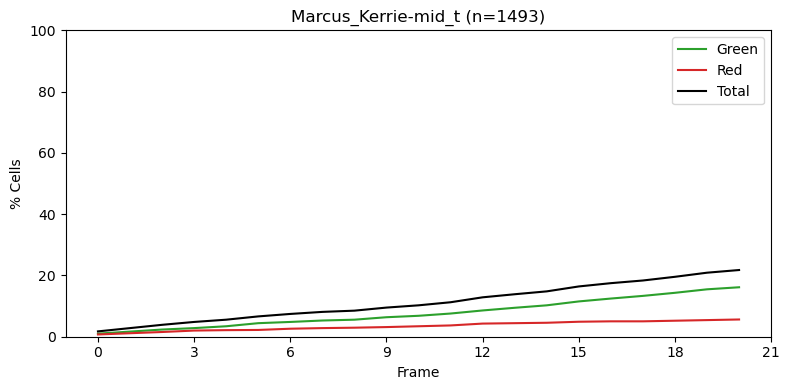

,frame,Green_pct,Red_pct,total_positive_pct
16,16,12.458138,5.023443,17.481581
17,17,13.328868,5.023443,18.352311
18,18,14.333557,5.224380,19.557937
19,19,15.472204,5.425318,20.897522
20,20,16.141996,5.626256,21.768252


In [ ]:
# Percentage curves
summary_persistent = compute_persistent_percentages(assignments_df, n_frames, fluorophore_names)
fig, ax = plot_persistent_percentages(summary_persistent, fluorophore_names, title=f"{tiff_path.stem} (n={len(assignments_df)})")
fig.savefig(work_dir / f"{tiff_path.stem}_persistent.png", dpi=150, bbox_inches="tight")
plt.show()

summary_persistent.tail()

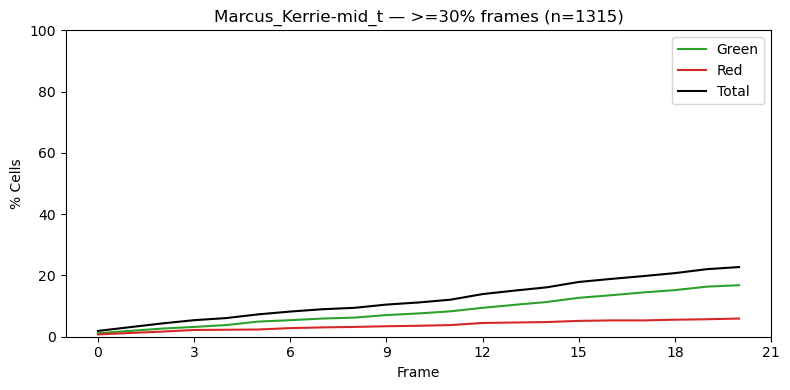

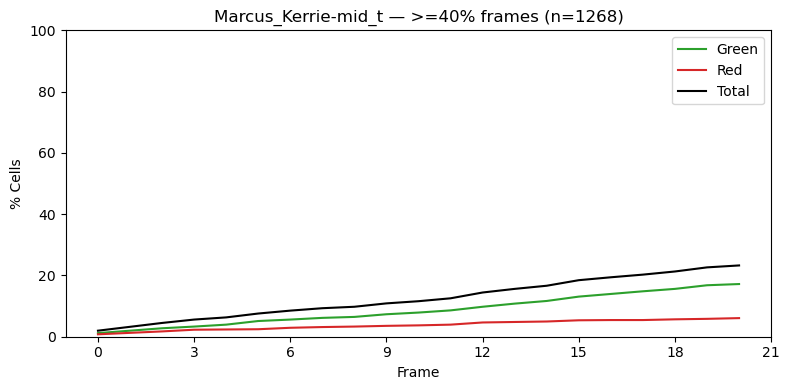

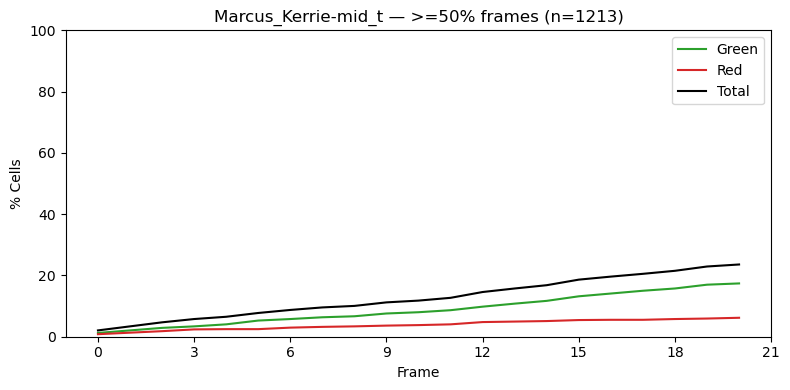

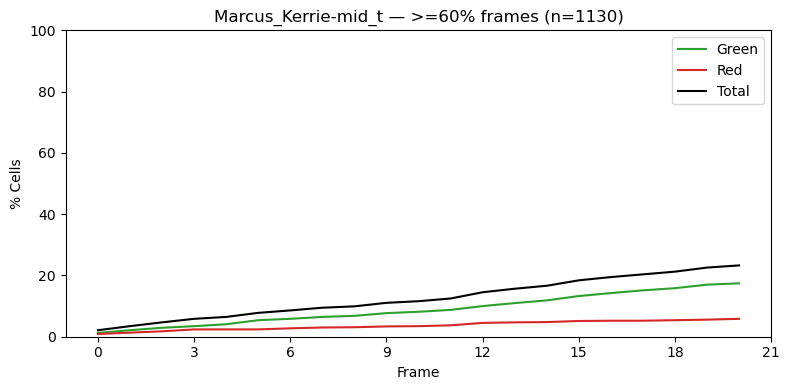

In [ ]:
# Filtered by frame presence
for cutoff in cutoff_pcts:
    filtered_assignments = filter_persistent_by_frame_presence(assignments_df, linked_labels, n_frames, cutoff)
    num_cells = len(filtered_assignments)
    if num_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue
    filtered_summary = compute_persistent_percentages(filtered_assignments, n_frames, fluorophore_names)
    fig, ax = plot_persistent_percentages(
        filtered_summary, fluorophore_names,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={num_cells})"
    )
    fig.savefig(work_dir / f"{tiff_path.stem}_persistent_cutoff{cutoff}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [11]:
# Per-frame data
print(f"Per-frame rows: {len(persistent_per_frame)}")
persistent_per_frame.head(10)

Per-frame rows: 23058


,label_id,frame,area,roundness,Green_positive_area,Red_positive_area,fate
0,1,0,3927.0,0.662129,0.0,0.0,negative
1,1,1,3919.0,0.574597,0.0,0.0,negative
2,1,2,3543.0,0.612697,0.0,0.0,negative
3,1,3,3488.0,0.809568,0.0,0.0,negative
4,1,4,3693.0,0.712039,0.0,0.0,negative
5,1,5,4316.0,0.740548,0.0,0.0,negative
6,1,6,2626.0,0.739666,0.0,0.0,negative
7,1,7,3962.0,0.391982,0.0,0.0,negative
8,1,8,3022.0,0.595148,0.0,0.0,negative
9,1,9,3395.0,0.539199,0.0,0.0,negative


In [20]:
# Build cumulative persistent labels: at frame t, only show cells whose
# first positive frame for that fate is <= t
cumulative_persistent = {}
for fluorophore_name in fluorophore_names:
    fate_cells = assignments_df.loc[
        assignments_df["fate"] == fluorophore_name,
        ["label_id", f"first_{fluorophore_name}_frame"],
    ]
    output_labels = np.zeros_like(linked_labels)
    for row_index, row in fate_cells.iterrows():
        label_id = int(row["label_id"])
        first_positive_frame = int(row[f"first_{fluorophore_name}_frame"])
        for frame_index in range(first_positive_frame, n_frames):
            mask = linked_labels[frame_index] == label_id
            output_labels[frame_index][mask] = label_id
    cumulative_persistent[fluorophore_name] = output_labels

viewer = napari.Viewer()
viewer.add_image(brightfield, name="Brightfield", colormap="gray")
add_coloured_labels(viewer, linked_labels, name="All cells", base_colour="gold", opacity=0.3)
for fluorophore_name in fluorophore_names:
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    add_coloured_labels(viewer, positive_cell_labels[fluorophore_name],
        name=f"{fluorophore_name} positive (this frame)",
        base_colour=get_fluor_base_colour(fluorophore_name), opacity=0.4)
    add_coloured_labels(viewer, cumulative_persistent[fluorophore_name],
        name=f"{fluorophore_name} persistent (cumulative)",
        base_colour=get_fluor_base_colour(fluorophore_name), opacity=0.5)
napari.run()

c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\c

---
## 4b. Snapshot analysis

In [21]:
snapshot_df = assign_snapshot_fates(linked_labels, frame_cell_pos)
snapshot_df = snapshot_df.sort_values(["label_id", "frame"]).reset_index(drop=True)

print(f"Snapshot rows: {len(snapshot_df)}")
print(f"Categories: {sorted(snapshot_df['category'].unique())}")
print(f"\nCategory distribution:\n{snapshot_df['category'].value_counts().to_string()}")
snapshot_df.head(10)

c:\Users\taylorhearn\git_repos\image_quantification\Annexin_V_Incucyte_Analysis\measurement.py:26: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = region.major_axis_length
c:\Users\taylorhearn\git_repos\image_quantification\Annexin_V_Incucyte_Analysis\measurement.py:27: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor_axis = region.minor_axis_length


Snapshot rows: 23058
Categories: ['Green', 'Green+Red', 'Red', 'negative']

Category distribution:
category
negative     21398
Red            917
Green          447
Green+Red      296


,label_id,frame,area,roundness,Green,Red,Green_positive_area,Red_positive_area,category
0,1,0,3927.0,0.662129,False,False,0.0,0.0,negative
1,1,1,3919.0,0.574597,False,False,0.0,0.0,negative
2,1,2,3543.0,0.612697,False,False,0.0,0.0,negative
3,1,3,3488.0,0.809568,False,False,0.0,0.0,negative
4,1,4,3693.0,0.712039,False,False,0.0,0.0,negative
5,1,5,4316.0,0.740548,False,False,0.0,0.0,negative
6,1,6,2626.0,0.739666,False,False,0.0,0.0,negative
7,1,7,3962.0,0.391982,False,False,0.0,0.0,negative
8,1,8,3022.0,0.595148,False,False,0.0,0.0,negative
9,1,9,3395.0,0.539199,False,False,0.0,0.0,negative


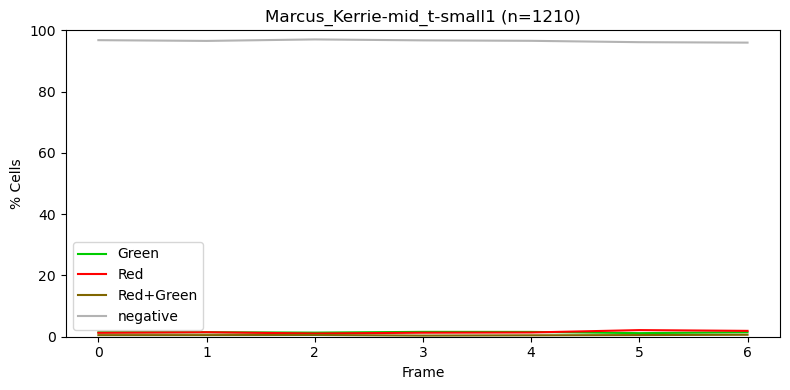

,frame,Green_pct,Red_pct,Red+Green_pct,negative_pct
2,2,1.339713,1.052632,0.574163,97.033493
3,3,1.590271,1.309635,0.374181,96.725912
4,4,1.572618,1.387604,0.462535,96.577243
5,5,1.169065,2.158273,0.539568,96.133094
6,6,1.458523,1.914312,0.638104,95.989061


In [ ]:
# Percentage curves
summary_snapshot, categories = compute_snapshot_percentages(snapshot_df, n_frames)
fig, ax = plot_snapshot_percentages(summary_snapshot, categories, title=f"{tiff_path.stem} (n={snapshot_df['label_id'].nunique()})")
fig.savefig(work_dir / f"{tiff_path.stem}_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()

summary_snapshot.tail()

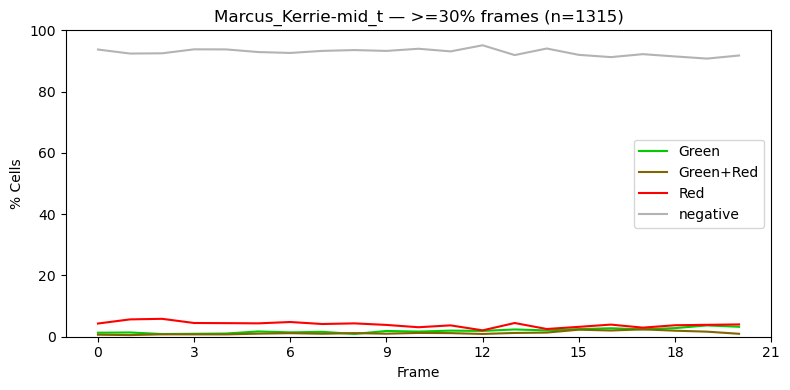

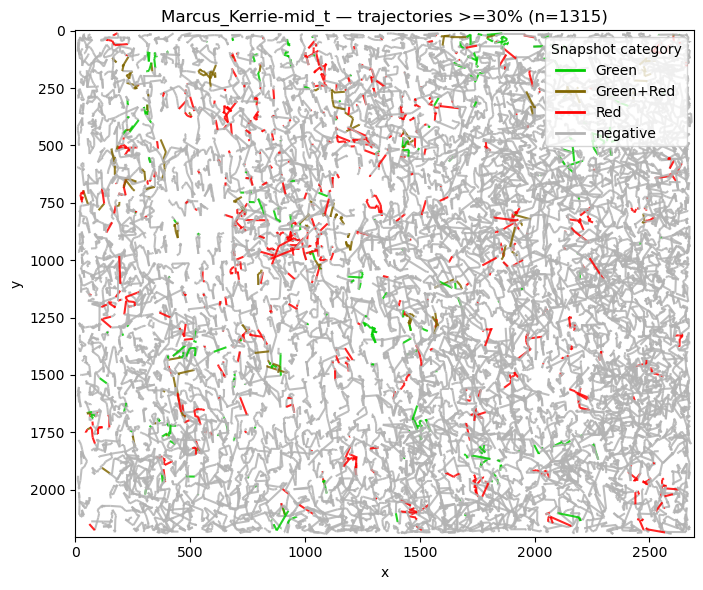

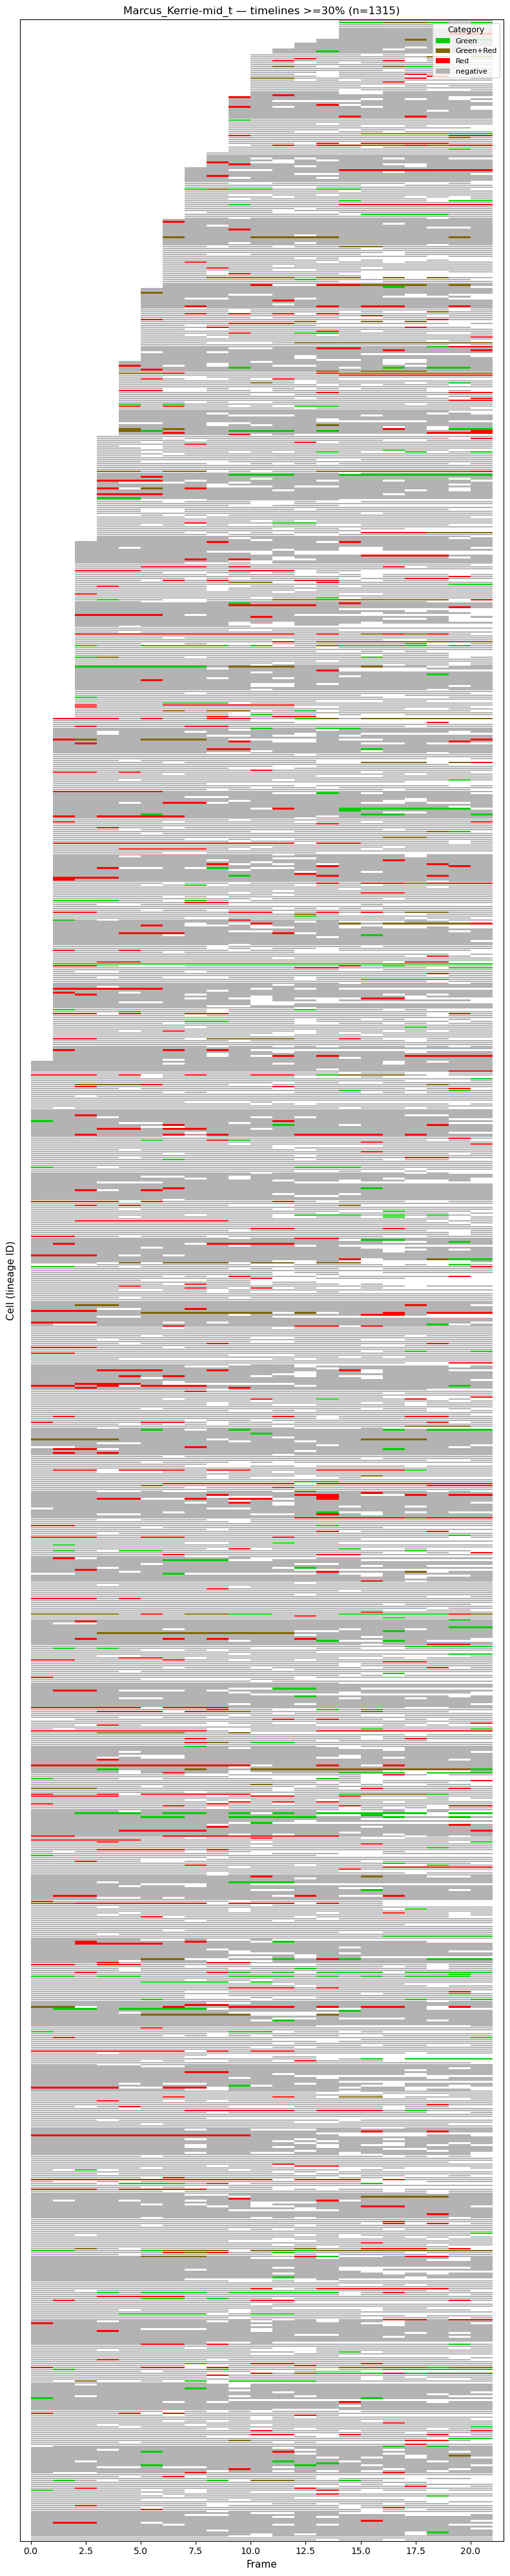

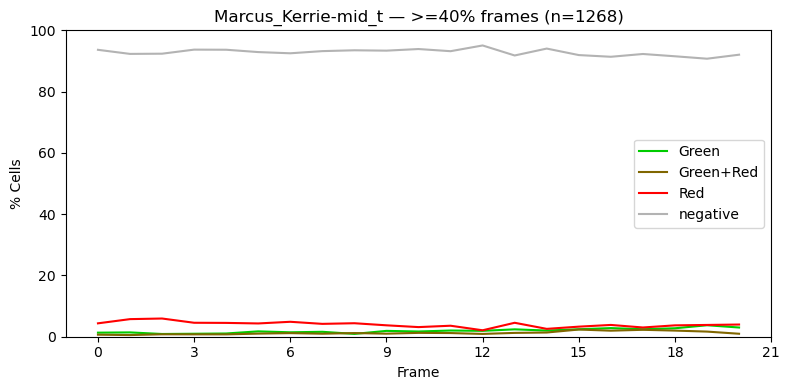

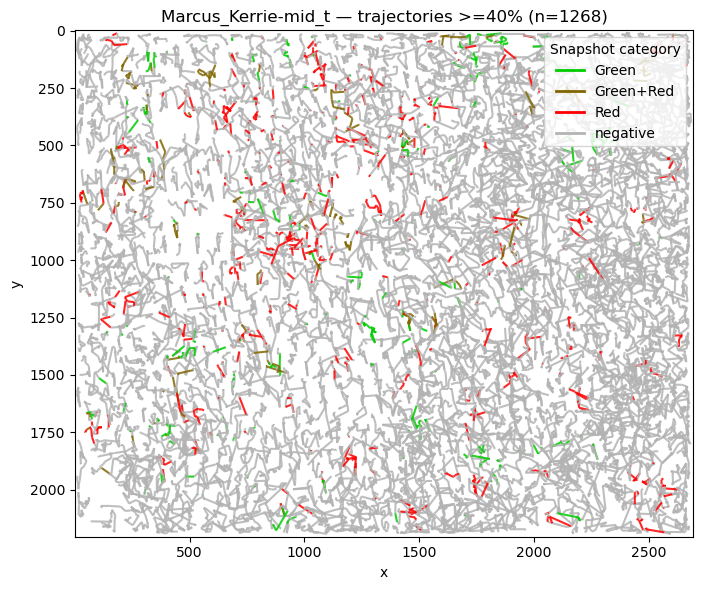

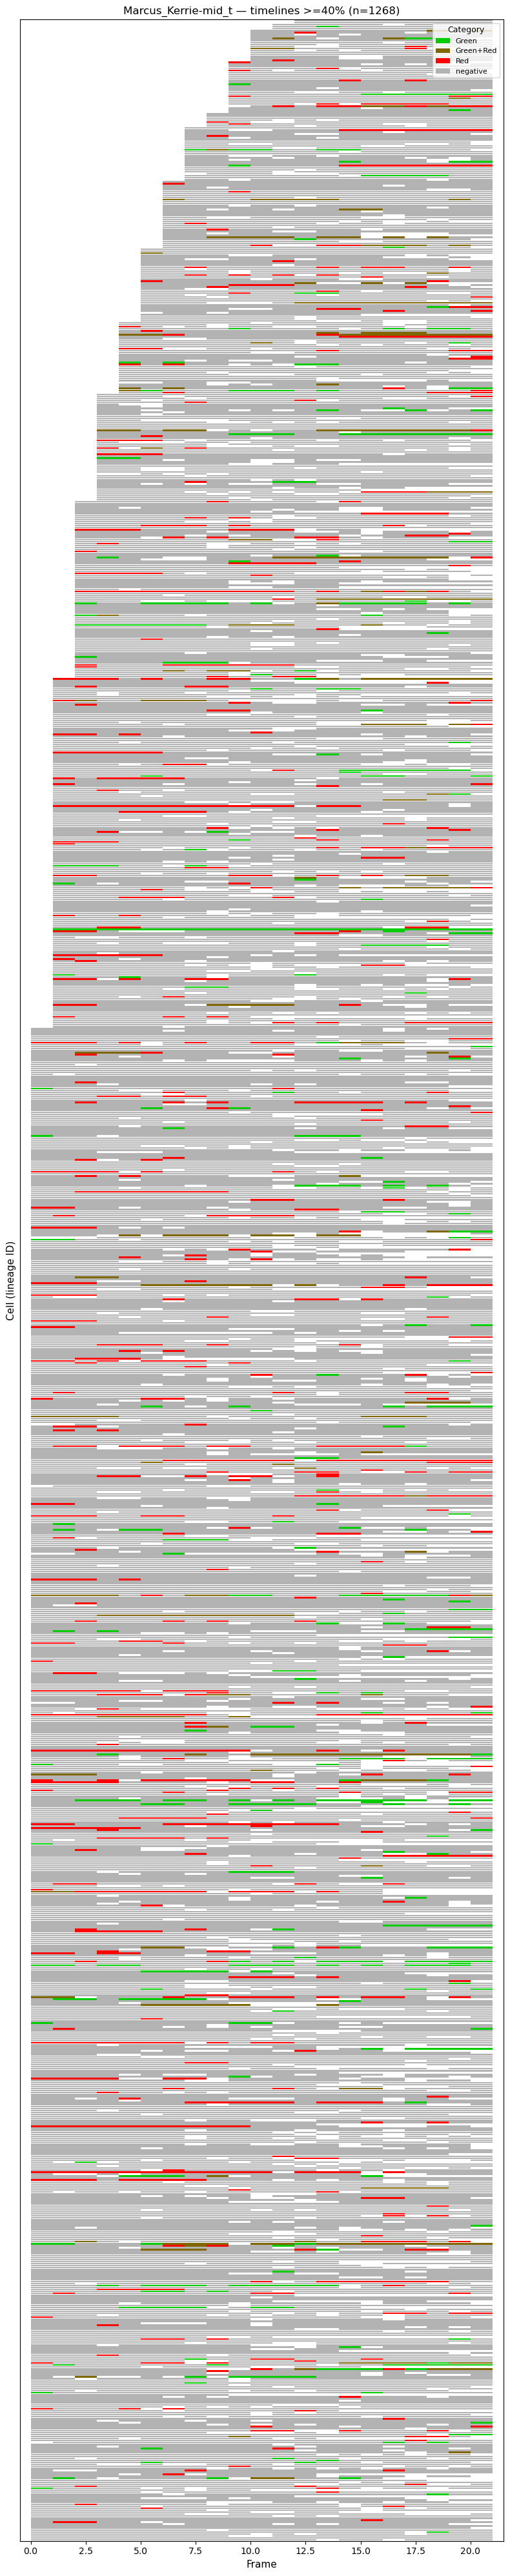

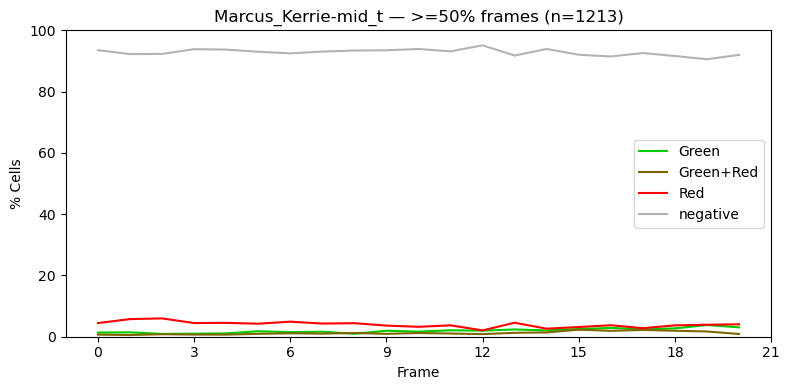

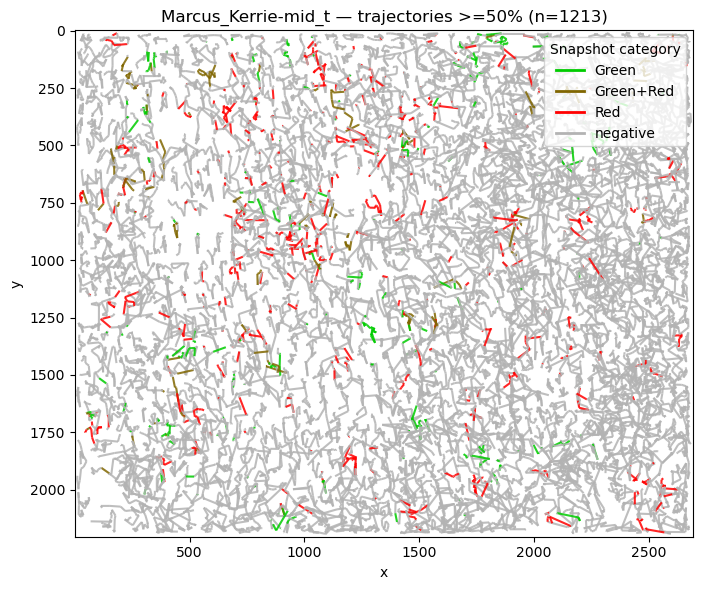

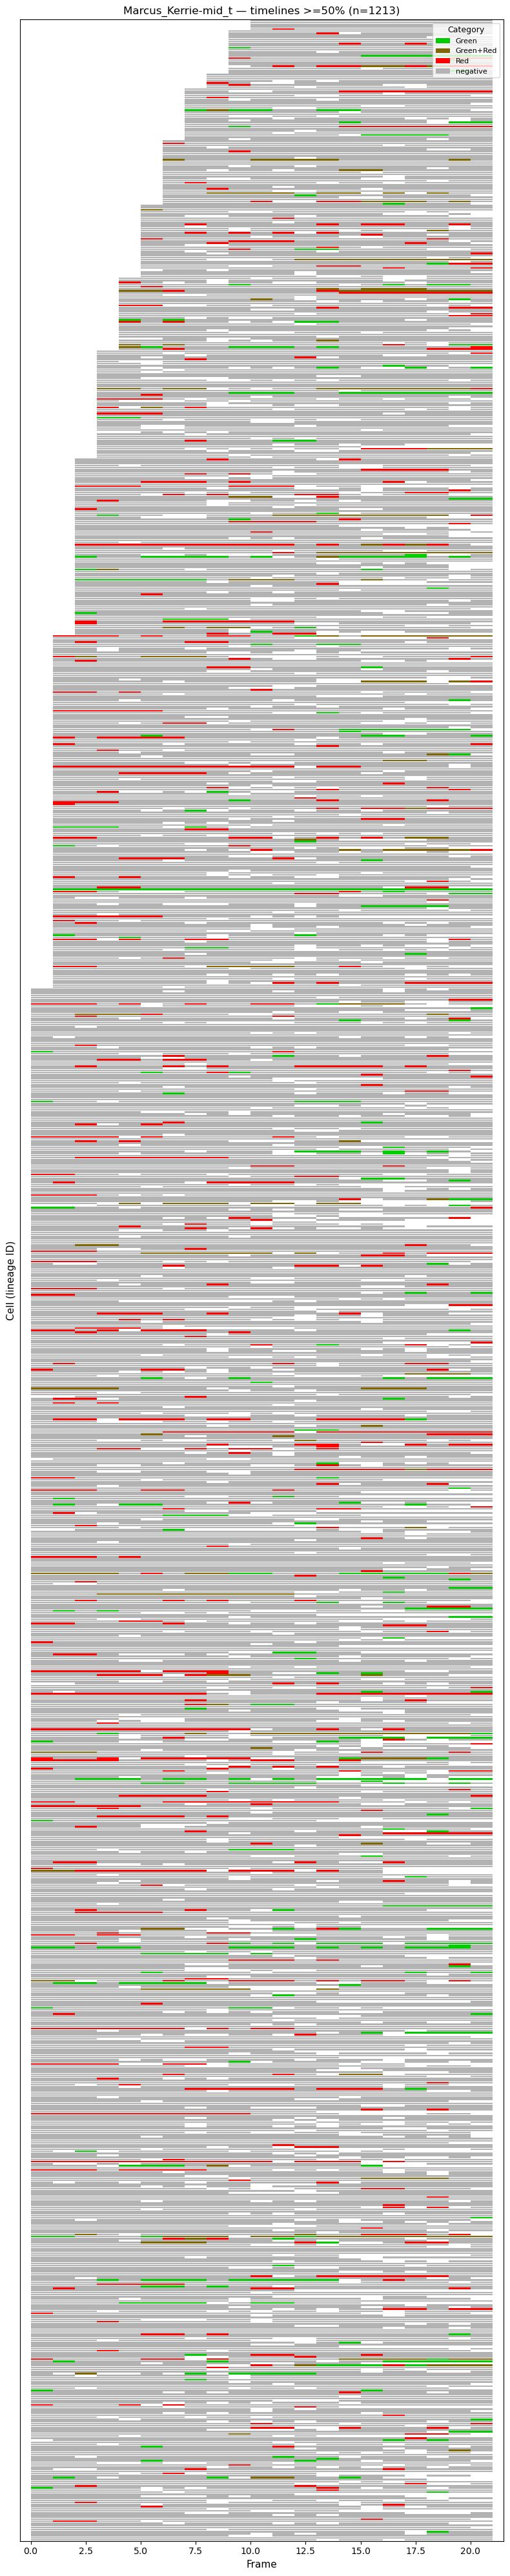

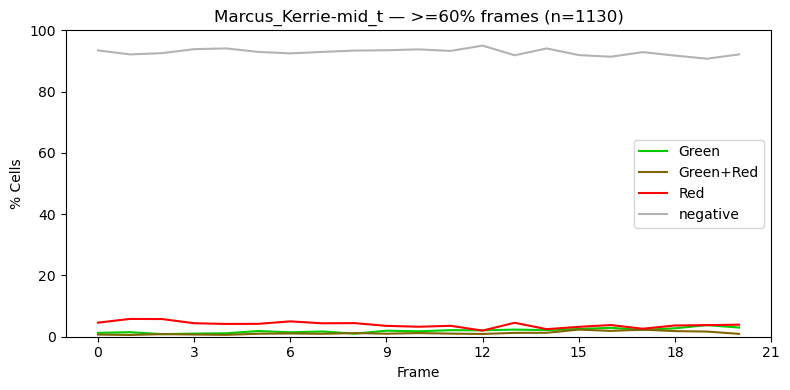

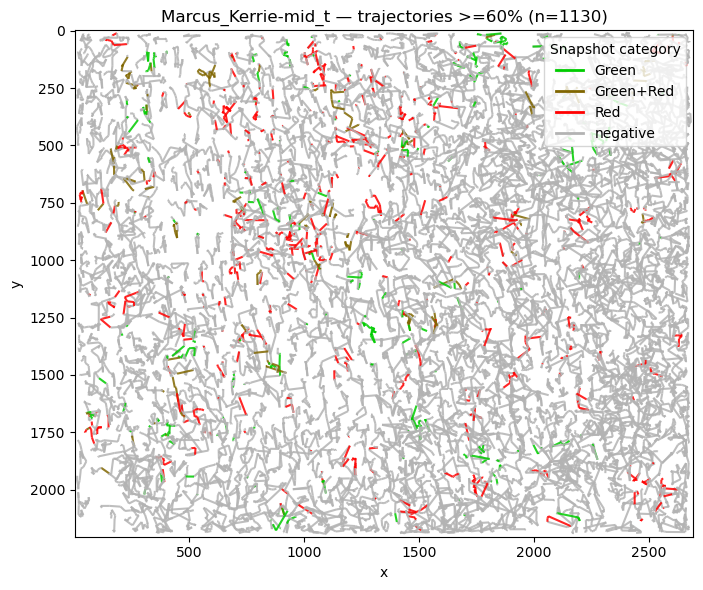

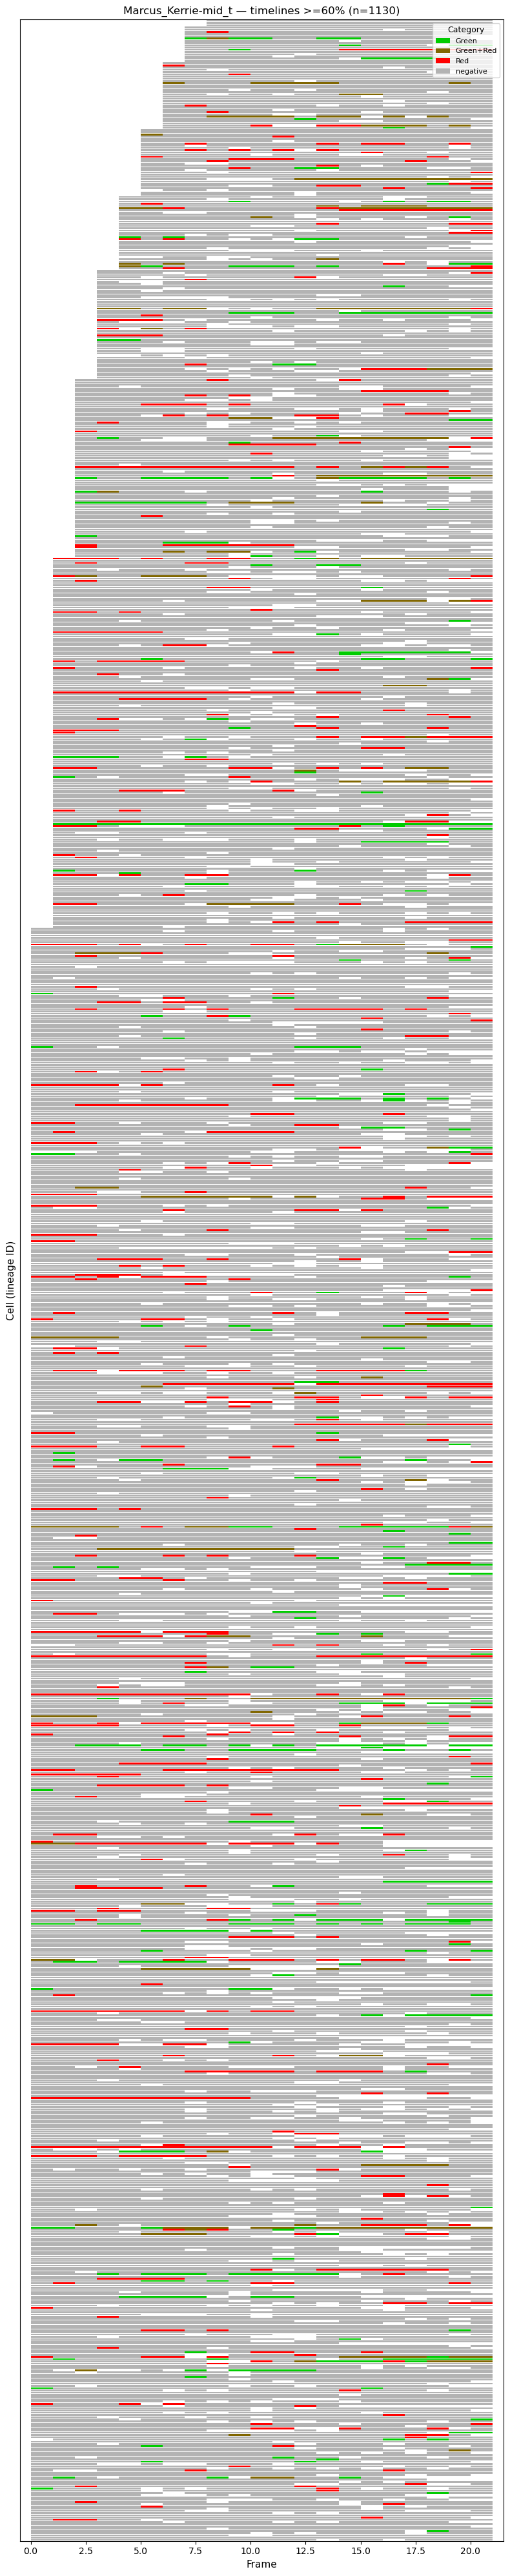

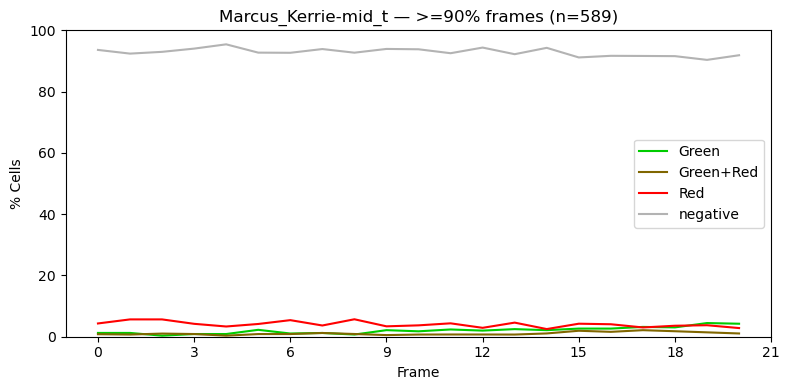

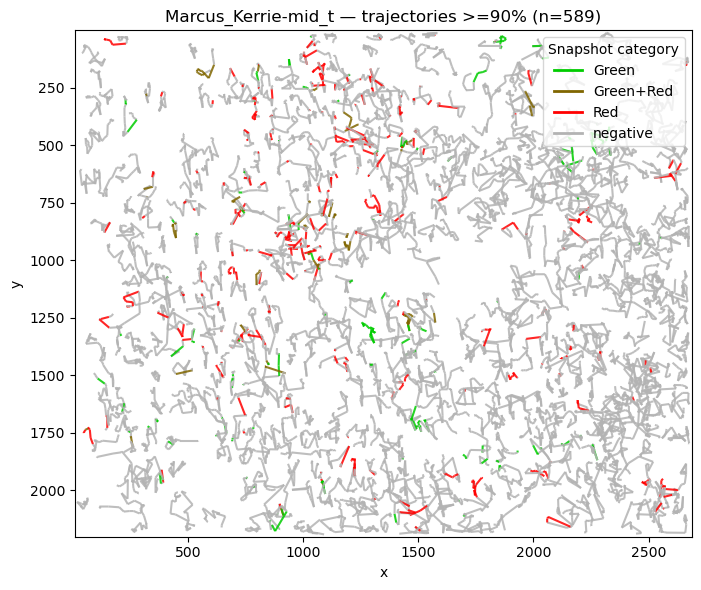

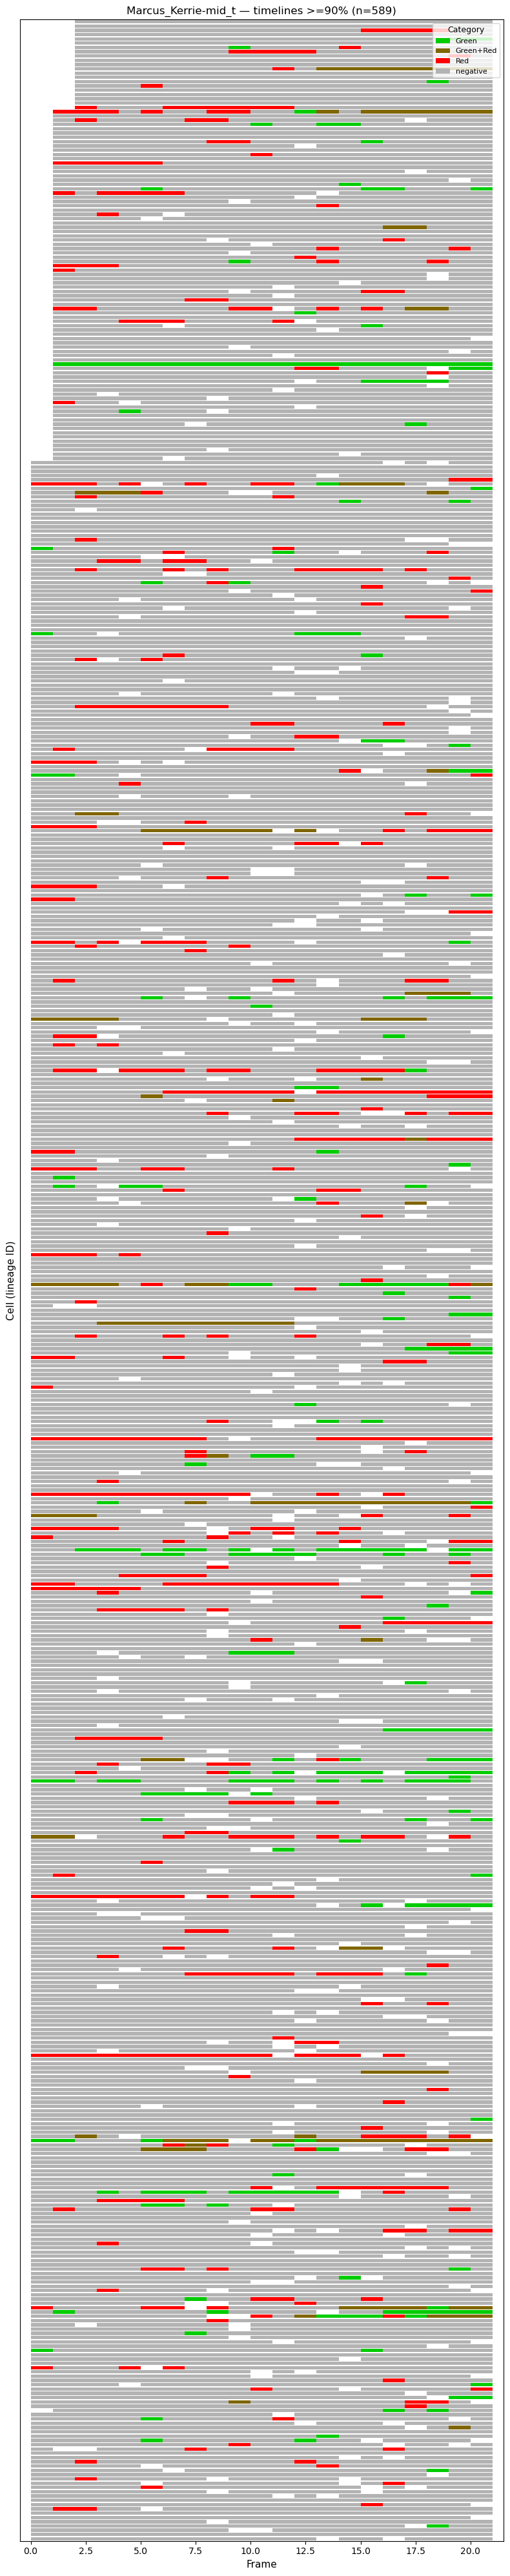

In [30]:
# Filtered by frame presence — percentages, trajectories, and timelines
for cutoff in cutoff_pcts:
    filtered_tracks, filtered_snapshot = filter_by_frame_presence(tracks_df, snapshot_df, n_frames, cutoff)
    num_cells = filtered_snapshot["label_id"].nunique() if len(filtered_snapshot) > 0 else 0
    if num_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue

    filtered_summary, filtered_categories = compute_snapshot_percentages(filtered_snapshot, n_frames)
    fig, ax = plot_snapshot_percentages(
        filtered_summary, filtered_categories,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={num_cells})"
    )
    fig.savefig(work_dir / f"{tiff_path.stem}_snapshot_cutoff{cutoff}.pdf", dpi=150, bbox_inches="tight")
    plt.show()

    if len(filtered_tracks) > 0:
        fig, ax = plot_snapshot_trajectories(
            filtered_tracks, filtered_snapshot,
            title=f"{tiff_path.stem} — trajectories >={cutoff}% (n={num_cells})"
        )
        fig.savefig(work_dir / f"{tiff_path.stem}_trajectories_cutoff{cutoff}.pdf", dpi=150, bbox_inches="tight")
        plt.show()

        fig, ax = plot_snapshot_cell_timelines(
            filtered_snapshot, tracks_df=filtered_tracks,
            title=f"{tiff_path.stem} — timelines >={cutoff}% (n={num_cells})"

        )        
        plt.show()
        fig.savefig(work_dir / f"{tiff_path.stem}_timelines_cutoff{cutoff}.pdf", dpi=150, bbox_inches="tight")

In [23]:
# Build per-category label images from snapshot data
snapshot_category_labels = {}
for category in sorted(snapshot_df["category"].unique()):
    category_stack = np.zeros_like(linked_labels)
    category_rows = snapshot_df[snapshot_df["category"] == category]
    for frame_index, frame_group in category_rows.groupby("frame"):
        cell_ids = frame_group["label_id"].to_numpy(dtype=np.uint32)
        is_in_category = np.isin(linked_labels[frame_index], cell_ids)
        category_stack[frame_index] = np.where(is_in_category, linked_labels[frame_index], 0)
    snapshot_category_labels[category] = category_stack

# Map each snapshot category to a base colour from its constituent fluorophores
def get_category_base_colour(category_name, fluorophore_names):
    matches = [fn for fn in fluorophore_names if fn.lower() in category_name.lower()]
    if len(matches) == 1:
        return get_fluor_base_colour(matches[0])
    elif len(matches) > 1:
        return "gold"       # multi-positive
    return "slategray"      # Negative / unknown

viewer = napari.Viewer()
viewer.add_image(brightfield, name="Brightfield", colormap="gray")
add_coloured_labels(viewer, linked_labels, name="All cells", base_colour="gold", opacity=0.3)
for fluorophore_name in fluorophore_names:
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    add_coloured_labels(viewer, positive_cell_labels[fluorophore_name],
        name=f"{fluorophore_name} positive (this frame)",
        base_colour=get_fluor_base_colour(fluorophore_name), opacity=0.4)
for category, category_stack in snapshot_category_labels.items():
    add_coloured_labels(viewer, category_stack,
        name=f"Snapshot: {category}",
        base_colour=get_category_base_colour(category, fluorophore_names), opacity=0.5)
napari.run()

c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\colormaps\colormap.py:468: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\cell-death\Lib\site-packages\napari\utils\c

---
## 5. Save outputs (optional)

In [ ]:
# assignments_df.to_csv(work_dir / "assignments_persistent.csv", index=False)
# persistent_per_frame.to_csv(work_dir / "persistent_per_frame.csv", index=False)
# snapshot_df.to_csv(work_dir / "snapshot.csv", index=False)
# summary_persistent.to_csv(work_dir / "percentages_persistent.csv", index=False)
# summary_snapshot.to_csv(work_dir / "percentages_snapshot.csv", index=False)

# print(f"Saved 5 CSVs to {work_dir}")